# QuTiP example: Groundstate of an ultra-strong coupled atom-cavity system

Authors: J.R. Johansson and P.D. Nation

Modified: C. Staufenbiel, 2022

### Introduction
In this example we will study the a coupled atom-cavity system. Instead of looking at the time evolution of such a system, we study the ground state of the atom and the cavity for increasing coupling strength between both systems.
We will observe that the rotating-wave approximation fails when the coupling strength is too large.

First we do some imports.

In [1]:
from base64 import b64encode

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from qutip import (about, destroy, expect, ket2dm, plot_wigner, ptrace, qeye,
                   tensor)

%matplotlib inline

Define the operators for the atom-cavity system. The first system is the cavity and the second the atom (in the tensor product). Here you can also choose to activate the rotating-wave approach. We will later store the expecation values for $\langle n \rangle$ in the lists we define at the end of the cell.

In [2]:
# Operators for the hamiltonian
N = 20  # number of cavity fock states
a = tensor(destroy(N), qeye(2))
sm = tensor(qeye(N), destroy(2))
nc = a.dag() * a
na = sm.dag() * sm

# Setup system frequencies
wc = 1.0 * 2 * np.pi  # cavity frequency
wa = 1.0 * 2 * np.pi  # atom frequency

use_rwa = False  # Set to True to see that non-RWA is necessary in this regime
glist = np.linspace(0, 2.5, 50) * 2 * np.pi  # coupling strength vector

# Lists of expectation values <n> for atom and cavity
na_expt = np.zeros(glist.shape)
nc_expt = np.zeros(glist.shape)
# List of ground states
gnd_states = []

The hamiltonian is defined as a function, since it depends on the varying coupling strength and the coice of the rotating wave approach.

In [3]:
def hamiltonian(g, use_rwa):
    if use_rwa:
        return wc * nc + wa * na + g * (a.dag() * sm + a * sm.dag())
    else:
        return wc * nc + wa * na + g * (a.dag() + a) * (sm + sm.dag())

Now we calculate the expecation values $\langle n_{atom} \rangle$ and $\langle n_{cavity} \rangle$, and the ground states of the full system for the different coupling strengths $g$.

In [4]:
for i, g in enumerate(glist):
    # obtain hamiltonian
    H = hamiltonian(g, use_rwa)
    # calculate energies and ground state
    evals, ekets = H.eigenstates()
    gnd_states.append(ekets[0])
    # expectation values for atom and cavity
    na_expt[i] = expect(na, ekets[0])
    nc_expt[i] = expect(nc, ekets[0])

Here we plot the expectation values depending on the coupling strength. If the RWA is deactivated, you see an increasing gap between $\langle n_{atom} \rangle$ and $\langle n_{cavity} \rangle$. For the RWA both expectation values are the same and follow a step function. This result is not the expected outcome.

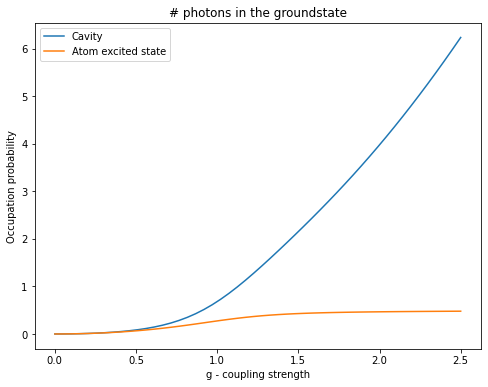

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(glist / (2 * np.pi), nc_expt)
ax.plot(glist / (2 * np.pi), na_expt)
ax.legend(("Cavity", "Atom excited state"))
ax.set_xlabel("g - coupling strength")
ax.set_ylabel("Occupation probability")
ax.set_title("# photons in the groundstate");

We can also visualise the ground state of the cavity using the Wigner distribution. Here we display the ground state for the strongest coupling between atom and cavity.

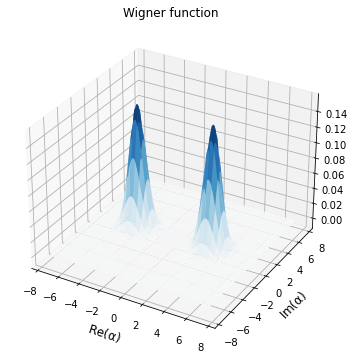

In [6]:
# obtain last state (strongest coupling) for the cavity
rhoss_final = ket2dm(gnd_states[-1])
rho_cavity = ptrace(rhoss_final, 0)

# plot wigner function
plot_wigner(rho_cavity, projection="3d");

To display the evolution of the cavity ground state with the coupling strenght we can add an animation using `plot_wigner`. The following code creates this animation. We can see how the ground state shifts from having one maximum to having two maxima.

In [7]:
# Function to display animation
def display_embedded_video(filename):
    video = open(filename, "rb").read()
    video_encoded = b64encode(video).decode("ascii")
    video_tag = '<video controls alt="test" \
        src="data:video/x-m4v;base64,{0}">'.format(
        video_encoded
    )
    return HTML(video_tag)


# Create animation
fig, ax = plt.subplots(1, 1, figsize=(10, 10))


def update(n):
    tmp = ket2dm(gnd_states[n])
    rho_cavity = ptrace(tmp, 0)
    plot_wigner(rho_cavity, fig=fig, ax=ax)
    return ax.artists


anim = animation.FuncAnimation(fig, update, frames=len(gnd_states), blit=True)
anim.save("animation-ground-state-ultrastrong.mp4", fps=10, writer="ffmpeg")
plt.close(fig)

# Display animation
display_embedded_video("animation-ground-state-ultrastrong.mp4")

## Software version:

In [8]:
about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Jake Lishman, Simon Cross and Asier Galicia.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.0.0.dev0+67add84
Numpy Version:      1.22.4
Scipy Version:      1.8.1
Cython Version:     0.29.30
Matplotlib Version: 3.5.2
Python Version:     3.10.4
Number of CPUs:     2
BLAS Info:          Generic
OPENMP Installed:   False
INTEL MKL Ext:      False
Platform Info:      Linux (x86_64)
Installation path:  /home/runner/work/qutip-tutorials/qutip-tutorials/qutip/qutip
Please cite QuTiP in your publication.
For your convenience a bibtex reference can b